<a href="https://colab.research.google.com/github/adombe/Machine_Learning_2026-/blob/main/Exercicio_1_de_Machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Install and import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Mount Google Drive (optional, for saving)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Cell 2: Load the wine quality dataset
# You can download from UCI or use this URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"
data = pd.read_csv(url, sep=';')

# Display basic info
print("Dataset shape:", data.shape)
print("\nFirst few rows:")
print(data.head())
print("\nDataset info:")
print(data.info())

Dataset shape: (4898, 12)

First few rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         0.32             8.5      0.058   
4            7.2              0.23         0.32             8.5      0.058   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 45.0                 170.0   1.0010  3.00       0.45   
1                 14.0                 132.0   0.9940  3.30       0.49   
2                 30.0                  97.0   0.9951  3.26       0.44   
3                 47.0                 186.0   0.9956  3.19       0.40   
4                 47.0                 186.0   0.9956  3.19       0.40   

   alcohol  quality  
0      8.8        6  

In [3]:
# Cell 3: Separate features (input) and target (output)
# Input: all columns except 'quality'
X = data.drop('quality', axis=1).values  # Input features
y = data['quality'].values.reshape(-1, 1)  # Output (target)

print(f"Input shape: {X.shape}")
print(f"Output shape: {y.shape}")
print(f"Number of input features: {X.shape[1]}")

Input shape: (4898, 11)
Output shape: (4898, 1)
Number of input features: 11


In [4]:
# Cell 4: Split data into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train dataset size: {X_train.shape[0]} examples")
print(f"Test dataset size: {X_test.shape[0]} examples")

Train dataset size: 3918 examples
Test dataset size: 980 examples


In [5]:
# Cell 5: Scale the input features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Scale the target variable too (optional but helps with neural networks)
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

In [6]:
# Cell 6: Prepare data for PyTorch
# Convert to tensors
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test_scaled)

# Create datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders (this handles batching)
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Batch size: {batch_size}")
print(f"Number of batches in training: {len(train_loader)}")

Batch size: 64
Number of batches in training: 62


In [7]:
# Cell 7: Create the neural network model
class WineQualityModel(nn.Module):
    def __init__(self, input_size):
        super(WineQualityModel, self).__init__()
        self.layer1 = nn.Linear(input_size, 64)
        self.layer2 = nn.Linear(64, 32)
        self.layer3 = nn.Linear(32, 16)
        self.layer4 = nn.Linear(16, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.dropout(x)
        x = self.relu(self.layer2(x))
        x = self.dropout(x)
        x = self.relu(self.layer3(x))
        x = self.layer4(x)  # No activation for regression output
        return x

# Initialize the model
input_size = X_train.shape[1]
model = WineQualityModel(input_size)
print(model)

WineQualityModel(
  (layer1): Linear(in_features=11, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=32, bias=True)
  (layer3): Linear(in_features=32, out_features=16, bias=True)
  (layer4): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
)


In [8]:
# Cell 8: Set up loss function and optimizer
# Loss function: Mean Squared Error (MSE) for regression
criterion = nn.MSELoss()

# Optimizer: Adam
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Loss function: {criterion.__class__.__name__}")
print(f"Optimizer: {optimizer.__class__.__name__}")

Loss function: MSELoss
Optimizer: Adam


In [9]:
num_epochs = 100
train_losses = []

for epoch in range(num_epochs):
    model.train()  # Set model to training mode
    epoch_loss = 0

    # Iterate over batches
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Forward pass: make predictions
        outputs = model(inputs)

        # Calculate loss
        loss = criterion(outputs, targets)

        # Backward pass and optimization
        optimizer.zero_grad()  # Clear previous gradients
        loss.backward()         # Compute gradients
        optimizer.step()        # Update weights

        epoch_loss += loss.item()

        if batch_idx == 0 and epoch % 10 == 0:
            print(f"Epoch {epoch}, Batch {batch_idx}: Loss = {loss.item():.4f}")

    # Average loss for the epoch
    avg_epoch_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_epoch_loss)

    if epoch % 10 == 0:
        print(f'Epoch [{epoch}/{num_epochs}], Average Loss: {avg_epoch_loss:.4f}')

Epoch 0, Batch 0: Loss = 1.1798
Epoch [0/100], Average Loss: 0.9017
Epoch 10, Batch 0: Loss = 0.7324
Epoch [10/100], Average Loss: 0.6418
Epoch 20, Batch 0: Loss = 0.6804
Epoch [20/100], Average Loss: 0.6032
Epoch 30, Batch 0: Loss = 0.5696
Epoch [30/100], Average Loss: 0.5843
Epoch 40, Batch 0: Loss = 0.3965
Epoch [40/100], Average Loss: 0.5724
Epoch 50, Batch 0: Loss = 0.5636
Epoch [50/100], Average Loss: 0.5541
Epoch 60, Batch 0: Loss = 0.6411
Epoch [60/100], Average Loss: 0.5522
Epoch 70, Batch 0: Loss = 0.4547
Epoch [70/100], Average Loss: 0.5300
Epoch 80, Batch 0: Loss = 0.5602
Epoch [80/100], Average Loss: 0.5265
Epoch 90, Batch 0: Loss = 0.5829
Epoch [90/100], Average Loss: 0.5277


In [10]:
# Cell 10: Evaluate on test dataset
model.eval()  # Set model to evaluation mode
predictions = []
actuals = []

with torch.no_grad():  # No gradient calculation needed
    for inputs, targets in test_loader:
        outputs = model(inputs)
        predictions.append(outputs)
        actuals.append(targets)

# Concatenate all batches
predictions = torch.cat(predictions, dim=0)
actuals = torch.cat(actuals, dim=0)

# Inverse transform to get original scale
predictions_original = y_scaler.inverse_transform(predictions.numpy())
actuals_original = y_scaler.inverse_transform(actuals.numpy())

# Calculate MSE on original scale
mse = mean_squared_error(actuals_original, predictions_original)
print(f"Test MSE: {mse:.4f}")
print(f"Test RMSE: {np.sqrt(mse):.4f}")

Test MSE: 0.4392
Test RMSE: 0.6627


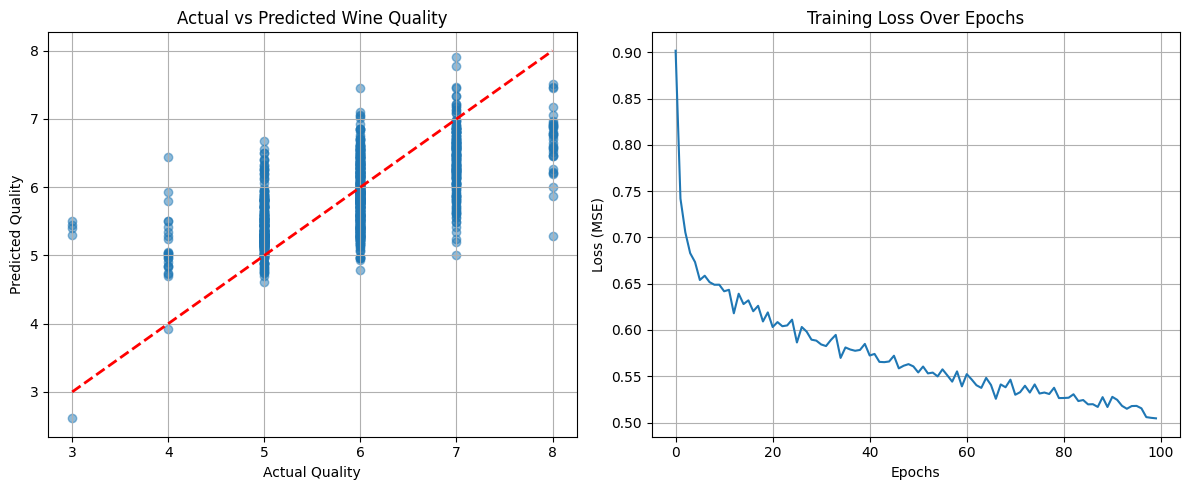

In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(actuals_original, predictions_original, alpha=0.5)
plt.plot([actuals_original.min(), actuals_original.max()],
         [actuals_original.min(), actuals_original.max()], 'r--', lw=2)
plt.xlabel('Actual Quality')
plt.ylabel('Predicted Quality')
plt.title('Actual vs Predicted Wine Quality')
plt.grid(True)

# Plot 2 - Loss vs Epochs
plt.subplot(1, 2, 2)
plt.plot(train_losses)
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss Over Epochs')
plt.grid(True)

plt.tight_layout()
plt.show()